<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_007_aprendizaje_supervisado/_007_arboles_de_decision/_007_02_Ejemplo_de_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este ejemplo está inspirado en la información que se encuentra en:

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

y

https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py


([], [])

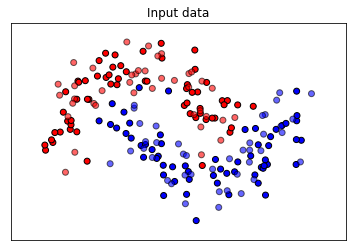

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.ensemble import RandomForestClassifier

X, y = make_moons(n_samples=200,noise=0.2, random_state=1970)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=.4, random_state=42)

x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# just plot the dataset first
cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])
ax = plt.figure()
plt.title("Input data")
# Plot the training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,
            edgecolors='k')
# Plot the testing points
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6,
            edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())


Puntos sólidos: Entrenamiento

Puntos semi-transparentes: Prueba

/usr/local/lib/python3.9/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.9/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.9/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForest

Tiempo 1
0.019587399700003515
[[37  2]
 [ 2 39]]


/usr/local/lib/python3.9/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Text(2.186925275208359, -2.6536716710913564, '.95')

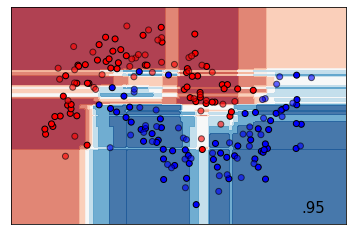

In [ ]:
clf = RandomForestClassifier(
          n_estimators =10,
          #integer, optional (default=100)
          criterion="gini",
          #string, optional (default=”gini”)
          max_depth=None,
          #integer or None, optional (default=None)
          min_samples_split=2,
          #int, float, optional (default=2)
          min_samples_leaf=1,
          #int, float, optional (default=1)
          min_weight_fraction_leaf=0.0,
          #float, optional (default=0.)
          max_features="auto",
          #int, float, string or None, optional (default=”auto”)
          max_leaf_nodes=None,
          #int or None, optional (default=None)
          min_impurity_decrease=0.0,
          #float, optional (default=0.)
          bootstrap=True,
          #boolean, optional (default=True)
          oob_score=False,
          #bool (default=False)
          n_jobs=None,
          #int or None, optional (default=None)
          random_state=None,
          #int, RandomState instance or None, optional (default=None)
          verbose=0,
          #int, optional (default=0)
          warm_start=False,
          #bool, optional (default=False)
          ccp_alpha=0.0,
          #non-negative float, optional (default=0.0)
          max_samples=None
          #int or float, default=None
          )
ax = plt.figure()
import timeit
time1 = timeit.timeit("clf.fit(X_train, y_train)",
                      setup="from __main__ import clf,X_train,y_train",
                      number=10)/10.0
print("Tiempo 1")
print(time1)
clf.fit(X_train, y_train)
y_predict = clf.predict(X_test)
CM = confusion_matrix(y_test, y_predict)
#[TP,FP;FN,TN]
print(CM)
score = clf.score(X_test, y_test)
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=cm, alpha=.8)

# Plot the training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,
          edgecolors='k')
# Plot the testing points
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright,
          edgecolors='k', alpha=0.6)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())
plt.text(xx.max() - .3, yy.min() + .3, ('%.2f' % score).lstrip('0'),
      size=15, horizontalalignment='right')
